# Stage 16 V2. Диагностика профиля общей blind spot группы

## Исследовательский вопрос

Имеет ли группа из 805 клиентов, которых одновременно пропустили все baseline-модели, наблюдаемый профиль в текущем пространстве 47 разрешённых признаков?

---

## Контекст исследования

На предыдущих этапах были получены следующие результаты:

- построен устойчивый baseline на 47 разрешённых признаках;
- исключены диагностические признаки `Q_B1_norm` и `Q_B2_norm`;
- проверены несколько различных семейств моделей;
- существенного улучшения качества не получено;
- выявлена общая группа ошибок baseline-моделей.

Следующий вопрос исследования изменяется:

Не "какая модель лучше?", а:

> Есть ли в текущих данных наблюдаемый профиль клиентов, которых не смогла обнаружить ни одна модель?

---

## Цель Stage 16 V2

Понять:

1. Является ли группа из 805 клиентов случайным набором сложных случаев.
2. Или эти клиенты имеют общие особенности в доступных признаках.
3. Может ли этот анализ указать направление поиска новой информации.

---

## Ограничения эксперимента

В этом исследовании:

- не обучаются новые модели;
- не изменяются признаки;
- не используется final test;
- не считаются метрики качества;
- не делаются причинные выводы.

Используются только:

- сохранённые Stage 3 OOF predictions;
- исходный dataset;
- 47 разрешённых признаков.

# 1. Восстановление общей группы пропущенных клиентов

## Исследовательский вопрос

Есть ли среди клиентов с фактическим дефолтом группа, которую не смогла обнаружить ни одна из базовых моделей?

---

## Зачем это проверять

После сравнения нескольких моделей было обнаружено, что часть клиентов с дефолтом остаётся незамеченной всеми моделями одновременно.

На этом этапе мы не ищем новую модель, а изучаем сами ошибки:

- действительно ли существует общая группа сложных клиентов;
- сколько таких клиентов;
- можно ли дальше исследовать их как отдельный тип случаев.

---

## Как определяется общая группа пропущенных клиентов

Клиент относится к общей группе пропущенных клиентов, если одновременно выполнены условия:

- фактический результат `DefMark = 1` (произошёл дефолт);
- CatBoost не обнаружил этот случай;
- XGBoost не обнаружил этот случай;
- LightGBM не обнаружил этот случай.

Таким образом, мы анализируем клиентов, которых пропустили все три baseline-модели.

---

## С чем будем сравнивать

Основная группа сравнения:

- **общая группа пропущенных клиентов** — клиенты, которых пропустили все модели;
- **остальные дефолтные клиенты** — другие клиенты с `DefMark = 1`, которые не вошли в эту группу.

Дополнительно недефолтные клиенты могут использоваться только для общего контекста.

---

## Ограничения

На этом этапе:

- новые модели не обучаются;
- предсказания не пересчитываются;
- метрики качества не считаются;
- final test не используется.

Мы только анализируем уже полученные результаты предыдущих этапов.

# 1.1 Загрузка результатов Stage 16

Загружаем сохранённый диагностический результат предыдущего этапа.

Он содержит:
- информацию о выделенной группе пропущенных клиентов;
- группы сравнения;
- профиль признаков;
- дополнительные диагностические показатели.

Новые модели не обучаются, используются только сохранённые результаты.

In [3]:
# ============================================================
# 1.2 Загрузка диагностического артефакта Stage 16
# Цель: проверить, что используемый результат получен из принятого
# диагностического этапа и содержит нужные группы клиентов.
# Новое обучение моделей и пересчёт предсказаний не выполняются.
# ============================================================

import json
from pathlib import Path


artifact_path = Path(
    "../reports/generated/stage16_blind_spot_inventory_V1.json"
)

with artifact_path.open("r", encoding="utf-8") as file:
    stage16 = json.load(file)


print("Артефакт Stage 16 загружен")
print()

print("Статус анализа:")
print(stage16["status"])

print()

print("Проверка ограничений:")
print("Использовался final test:", stage16["final_test_used"])
print("Обучение моделей выполнялось:", stage16["model_training_or_tuning_performed"])
print("Метрики качества рассчитывались:", stage16["quality_metrics_calculated"])

print()

print("Доступные разделы результата:")
for key in stage16.keys():
    print("-", key)

Артефакт Stage 16 загружен

Статус анализа:
DESCRIPTIVE_INVENTORY_COMPLETE

Проверка ограничений:
Использовался final test: False
Обучение моделей выполнялось: False
Метрики качества рассчитывались: False

Доступные разделы результата:
- stage
- status
- final_test_used
- model_training_or_tuning_performed
- quality_metrics_calculated
- sources
- input_sha256
- blind_spot
- comparison_groups
- analysis_parameters
- feature_profile
- missingness
- oof_score_profile
- limitations


## Результат

Артефакт Stage 16 успешно загружен.

Проверено:
- final test не использовался;
- обучение моделей не выполнялось;
- метрики качества не пересчитывались.

Переходим к проверке состава исследуемых групп.

# 1.2 Проверка состава исследуемых групп

Проверяем размеры групп, которые используются в дальнейшем анализе.

Нас интересует:

- сколько клиентов вошло в общую группу пропущенных случаев;
- сколько клиентов осталось среди остальных дефолтов;
- сколько клиентов находится в недефолтной группе для дополнительного контекста.

На этом этапе только подтверждаем корректность групп.

In [4]:
# ============================================================
# 1.2 Размеры исследуемых групп
# Цель: подтвердить состав групп перед сравнением признаков.
# Дополнительный анализ пока не выполняется.
# ============================================================

print("Размеры исследуемых групп")
print("=" * 40)

for group_name, group_info in stage16["comparison_groups"].items():
    print(f"{group_name}:")
    print(f"  Количество клиентов: {group_info}")
    print()

Размеры исследуемых групп
A_blind_spot_defaults:
  Количество клиентов: {'rows': 805, 'definition': 'accepted Stage 3 blind-spot defaults'}

B_other_defaults:
  Количество клиентов: {'rows': 27210, 'definition': 'all other working rows with DefMark = 1'}

C_non_defaults_context_only:
  Количество клиентов: {'rows': 261599, 'definition': 'working rows with DefMark = 0; descriptive context only'}



# 2. Профиль общей группы пропущенных клиентов

## Исследовательский вопрос

Отличается ли группа клиентов, которых пропустили все baseline-модели, от остальных клиентов с дефолтом?

---

## Зачем это проверять

Если общая группа пропущенных клиентов имеет устойчивые отличия по доступным признакам, это может указывать на наличие отдельного типа сложных случаев.

Если отличий нет, это усилит гипотезу, что текущие признаки не содержат достаточного сигнала для их выделения.

Сравниваем:

- общую группу пропущенных клиентов (805 строк);
- остальные дефолтные клиенты (27 210 строк).

Анализ является описательным и не доказывает причин влияния признаков.

In [5]:
# ============================================================
# 2.1 Сравнение профиля признаков двух групп
# Цель: найти признаки с наибольшими различиями между:
# - общей группой пропущенных клиентов;
# - остальными дефолтными клиентами.
#
# Используются только описательные статистики.
# Новое обучение моделей не выполняется.
# ============================================================

rows = []

for feature, data in stage16["feature_profile"].items():
    blind = data["groups"]["A_blind_spot_defaults"]
    other = data["groups"]["B_other_defaults"]

    mean_difference = blind["mean"] - other["mean"]
    effect_size = data["cohens_d"]["A_vs_B"]

    rows.append(
        {
            "Признак": feature,
            "Среднее_пропущенные": blind["mean"],
            "Среднее_остальные_дефолты": other["mean"],
            "Разница": mean_difference,
            "Размер_различия": effect_size,
        }
    )


# Сортировка по абсолютному размеру различия
rows = sorted(
    rows,
    key=lambda x: abs(x["Размер_различия"]),
    reverse=True
)


print("Топ признаков по различию групп")
print("=" * 90)

for row in rows[:20]:
    print(
        f"{row['Признак']:20} | "
        f"пропущенные={row['Среднее_пропущенные']:8.3f} | "
        f"дефолты={row['Среднее_остальные_дефолты']:8.3f} | "
        f"разница={row['Разница']:+8.3f} | "
        f"d={row['Размер_различия']:.3f}"
    )

Топ признаков по различию групп
Q_D6_norm            | пропущенные=  13.702 | дефолты= -26.604 | разница= +40.307 | d=1.181
Q_C1_norm            | пропущенные=   9.378 | дефолты= -24.027 | разница= +33.405 | d=0.949
Q_A5_norm            | пропущенные=  13.388 | дефолты= -39.838 | разница= +53.227 | d=0.852
D1_norm              | пропущенные=   7.934 | дефолты= -24.328 | разница= +32.262 | d=0.735
D5_norm              | пропущенные=  14.491 | дефолты= -35.077 | разница= +49.567 | d=0.683
D4_norm              | пропущенные=  14.611 | дефолты= -34.823 | разница= +49.434 | d=0.682
F1_norm              | пропущенные=   6.200 | дефолты= -19.432 | разница= +25.633 | d=0.666
Q_B3_norm            | пропущенные=  15.674 | дефолты= -32.072 | разница= +47.746 | d=0.613
A1_norm              | пропущенные=   9.785 | дефолты= -23.445 | разница= +33.231 | d=0.581
D3_norm              | пропущенные=   7.293 | дефолты= -22.157 | разница= +29.450 | d=0.541
A5_norm              | пропущенные=   8.277 | де

# Результат сравнения профиля групп

## ФАКТЫ

Сравнение общей группы пропущенных клиентов (805 строк) с остальными дефолтными клиентами (27 210 строк) показало заметные различия по нескольким признакам.

Наиболее выраженные различия наблюдаются у признаков:

- `Q_D6_norm`;
- `Q_C1_norm`;
- `Q_A5_norm`;
- `D1_norm`;
- `D5_norm`;
- `D4_norm`;
- `F1_norm`;
- `Q_B3_norm`.

Для ряда признаков размер различия между группами является существенным.

## ИНТЕРПРИТАЦИЯ

Общая группа пропущенных клиентов не выглядит случайным набором ошибок.

У этих клиентов наблюдается собственный профиль в текущем пространстве признаков:

- их значения по ряду признаков систематически отличаются от остальных дефолтных клиентов;
- существующие признаки содержат некоторую информацию, связанную с различием между этими группами.

Это означает, что проблема может быть не только в выборе алгоритма, а также в том, как текущие модели используют доступный сигнал.

## ОГРАНИЧЕНИЯ

Полученные различия являются описательными.

Они не доказывают:

- что конкретный признак является причиной дефолта;
- что изменение этих признаков улучшит качество модели;
- что новая модель сможет автоматически обнаружить эту группу.

Различие распределений не равно причинному влиянию.

## СЛЕДУЮЩИЙ ВОПРОС

> Является ли общая группа пропущенных клиентов одним однородным типом или внутри неё существуют разные подгруппы?

Если внутри 805 клиентов есть несколько разных профилей, то общий blind spot может состоять из нескольких независимых проблем.

# 3. Проверка внутренней структуры общей группы пропущенных клиентов

## Исследовательский вопрос

Является ли общая группа пропущенных клиентов однородной группой или внутри неё существуют разные типы клиентов?

---

## Зачем это проверять

Ранее мы увидели, что 805 клиентов имеют общий профиль, отличающийся от остальных дефолтных клиентов.

Теперь важно понять:

- все ли эти клиенты похожи между собой;
- или общая группа состоит из нескольких разных подтипов.

Если внутри группы есть разные подтипы, то одна общая причина пропуска может отсутствовать, и дальнейший поиск информации нужно будет вести отдельно для разных сегментов.

---

## Ограничения анализа

На этом этапе:

- не используются целевые значения для поиска групп;
- не обучаются модели;
- анализ используется только для описания структуры клиентов.

Цель — понять состав группы, а не построить новый предиктор.

# 3. Проверка внутренней структуры общей группы пропущенных клиентов

## Исследовательский вопрос

Является ли общая группа пропущенных клиентов однородной группой или внутри неё существуют разные типы клиентов?

---

## Зачем это проверять

Ранее мы увидели, что 805 клиентов имеют общий профиль, отличающийся от остальных дефолтных клиентов.

Теперь важно понять:

- все ли эти клиенты похожи между собой;
- или общая группа состоит из нескольких разных подтипов.

Если внутри группы есть разные подтипы, то одна общая причина пропуска может отсутствовать, и дальнейший поиск информации нужно будет вести отдельно для разных сегментов.

---

## Ограничения анализа

На этом этапе:

- не используются целевые значения для поиска групп;
- не обучаются модели;
- анализ используется только для описания структуры клиентов.

Цель — понять состав группы, а не построить новый предиктор.

# 3. Проверка внутренней структуры общей группы пропущенных клиентов

## Исследовательский вопрос

Является ли общая группа пропущенных клиентов однородной группой или внутри неё существуют разные типы клиентов?

---

## Зачем это проверять

Ранее мы увидели, что 805 клиентов имеют общий профиль, отличающийся от остальных дефолтных клиентов.

Теперь важно понять:

- все ли эти клиенты похожи между собой;
- или общая группа состоит из нескольких разных подтипов.

Если внутри группы есть разные подтипы, то одна общая причина пропуска может отсутствовать, и дальнейший поиск информации нужно будет вести отдельно для разных сегментов.

---

## Ограничения анализа

На этом этапе:

- не используются целевые значения для поиска групп;
- не обучаются модели;
- анализ используется только для описания структуры клиентов.

Цель — понять состав группы, а не построить новый предиктор.

# 3. Проверка внутренней структуры общей группы пропущенных клиентов

## Исследовательский вопрос

Является ли общая группа пропущенных клиентов однородной группой или внутри неё существуют разные типы клиентов?

---

## Зачем это проверять

Ранее мы увидели, что 805 клиентов имеют общий профиль, отличающийся от остальных дефолтных клиентов.

Теперь важно понять:

- все ли эти клиенты похожи между собой;
- или общая группа состоит из нескольких разных подтипов.

Если внутри группы есть разные подтипы, то одна общая причина пропуска может отсутствовать, и дальнейший поиск информации нужно будет вести отдельно для разных сегментов.

---

## Ограничения анализа

На этом этапе:

- не используются целевые значения для поиска групп;
- не обучаются модели;
- анализ используется только для описания структуры клиентов.

Цель — понять состав группы, а не построить новый предиктор.

In [6]:
# ============================================================
# 3.1 Проверка внутреннего разброса общей группы пропущенных клиентов
# Цель: понять, насколько однородна группа из 805 клиентов.
# Используются только описательные статистики.
# Кластеризация и обучение моделей не выполняются.
# ============================================================

import pandas as pd


# Берём признаки с наибольшими различиями из предыдущего анализа
top_features = [
    "Q_D6_norm",
    "Q_C1_norm",
    "Q_A5_norm",
    "D1_norm",
    "D5_norm",
    "D4_norm",
    "F1_norm",
    "Q_B3_norm",
]


rows = []

for feature in top_features:
    data = stage16["feature_profile"][feature]["groups"]["A_blind_spot_defaults"]

    rows.append(
        {
            "Признак": feature,
            "Количество": data["n"],
            "Среднее": data["mean"],
            "Медиана": data["median"],
            "Стандартное отклонение": data["std"],
            "P10": data["q05"],
            "P25": data["q25"],
            "P75": data["q75"],
            "P90": data["q95"],
        }
    )


profile_table = pd.DataFrame(rows)

profile_table

,Признак,Количество,Среднее,Медиана,Стандартное отклонение,P10,P25,P75,P90
0,Q_D6_norm,805,13.702329,64.1797,51.586902,-38.95300,-38.9530,64.1797,64.17970
1,Q_C1_norm,805,9.377554,-34.8407,52.447158,-34.84070,-34.8407,67.9369,67.93690
2,Q_A5_norm,805,13.388435,24.7409,36.533247,-60.72310,24.7409,42.4527,43.75480
3,D1_norm,805,7.933793,-7.4257,48.886574,-58.53640,-22.4015,33.0178,112.65390
4,D5_norm,805,14.490512,16.9236,21.803892,1.57830,16.1157,19.5392,27.80820
5,D4_norm,805,14.611144,17.0079,21.556143,2.63504,15.3773,19.9571,28.46332
6,F1_norm,805,6.200419,2.6523,50.125679,-41.54910,2.6523,2.6523,174.25630
7,Q_B3_norm,805,15.673609,18.8384,18.465219,18.83840,18.8384,18.8384,18.83840


# Результат проверки внутреннего разброса группы

## Вывод

Внутри общей группы пропущенных клиентов наблюдается различный уровень разброса значений признаков.

Наиболее неоднородными выглядят признаки:

- `Q_D6_norm`;
- `Q_C1_norm`;
- `D1_norm`;
- `F1_norm`.

По некоторым признакам значения клиентов сильно отличаются между собой, а по другим группа выглядит более компактной.

## Интерпретация

Общая группа пропущенных клиентов не выглядит полностью однородной.

Это означает, что 805 случаев могут включать разные типы клиентов, которые имеют общий результат — были пропущены всеми моделями, но могут отличаться по своим характеристикам.

Однако одного анализа разброса недостаточно, чтобы выделить отдельные подгруппы.

## Ограничения

Этот анализ показывает только различия внутри группы.

Он не определяет:

- количество возможных подтипов;
- границы между ними;
- то, что найденные группы имеют разную природу.

## Следующий вопрос

Можно ли выделить внутри 805 клиентов несколько устойчивых групп по доступным признакам?

# 3.3 Проверка структуры признаков внутри группы

Перед поиском возможных подгрупп проверяем структуру основных признаков.

Цель:

- понять, являются ли признаки достаточно разнообразными внутри группы;
- проверить наличие пропусков и повторяющихся значений;
- подготовить данные для дальнейшего описательного анализа.

На этом этапе группы не выделяются.

In [7]:
# ============================================================
# 3.2 Проверка уникальности и пропусков признаков
# Цель: оценить структуру данных внутри общей группы
# пропущенных клиентов.
# Кластеризация и обучение моделей не выполняются.
# ============================================================

import pandas as pd


rows = []

for feature in top_features:
    data = stage16["feature_profile"][feature]["groups"]["A_blind_spot_defaults"]

    rows.append(
        {
            "Признак": feature,
            "Количество клиентов": data["n"],
            "Без пропусков": data["non_missing_n"],
            "Доля заполненных": round(data["non_missing_n"] / data["n"] * 100, 1),
            "Минимум": data["q05"],
            "Максимум": data["q95"],
        }
    )


structure_table = pd.DataFrame(rows)

structure_table

,Признак,Количество клиентов,Без пропусков,Доля заполненных,Минимум,Максимум
0,Q_D6_norm,805,805,100.0,-38.95300,64.17970
1,Q_C1_norm,805,805,100.0,-34.84070,67.93690
2,Q_A5_norm,805,805,100.0,-60.72310,43.75480
3,D1_norm,805,805,100.0,-58.53640,112.65390
4,D5_norm,805,805,100.0,1.57830,27.80820
5,D4_norm,805,805,100.0,2.63504,28.46332
6,F1_norm,805,805,100.0,-41.54910,174.25630
7,Q_B3_norm,805,805,100.0,18.83840,18.83840


# Результат проверки структуры признаков

## Вывод

Для выбранных признаков общей группы пропущенных клиентов:

- все 805 клиентов имеют заполненные значения;
- признаки содержат различный диапазон значений;
- проблема не связана с наличием пропусков в данных.

## Интерпретация

Общая группа пропущенных клиентов не является простой группой клиентов с отсутствующими данными.

Разброс значений показывает, что внутри группы могут существовать разные варианты поведения клиентов.

Следовательно, следующий анализ можно проводить по самим значениям признаков, а не по качеству заполнения данных.

## Ограничения

Проверены только основные признаки, показавшие наибольшие различия между группами.

Этот анализ не определяет наличие конкретных подгрупп внутри 805 клиентов.

## Следующий вопрос

Есть ли внутри общей группы пропущенных клиентов несколько устойчивых сегментов по доступным признакам?

# 4. Подготовка к поиску подгрупп внутри общей группы пропущенных клиентов

## Исследовательский вопрос

Содержит ли общая группа пропущенных клиентов несколько разных типов клиентов?

---

## Подход

Проверяем только структуру самой группы из 805 клиентов.

Используем:

- только 47 разрешённых признаков;
- только клиентов из общей группы пропущенных случаев;
- только значения признаков.

Не используем:

- целевой признак `DefMark`;
- предсказания моделей;
- метрики качества.

Цель анализа — не построить новую модель, а понять, есть ли внутри сложной группы разные профили клиентов.

In [8]:
# ============================================================
# 4.1 Подготовка данных для описательной сегментации
# Цель: собрать таблицу признаков только для 805 клиентов
# общей группы пропущенных случаев.
#
# Target и модельные предсказания не используются.
# ============================================================

import pandas as pd


# Проверяем наличие подготовленных данных из артефакта
print("Подготовка данных для анализа структуры группы")

print()
print("Количество клиентов в группе:")
print(stage16["comparison_groups"]["A_blind_spot_defaults"]["rows"])

print()
print("Используемые ограничения:")
print("- только признаки")
print("- без DefMark")
print("- без предсказаний моделей")
print("- без обучения")

Подготовка данных для анализа структуры группы

Количество клиентов в группе:
805

Используемые ограничения:
- только признаки
- без DefMark
- без предсказаний моделей
- без обучения


# 4.2 Восстановление таблицы клиентов для анализа

Для поиска возможных подгрупп необходимо получить исходные строки клиентов, которые входят в общую группу пропущенных случаев.

Используем:

- исходный датасет;
- сохранённые индексы группы из Stage 3;
- только 47 разрешённых признаков.

Целевой признак `DefMark` и предсказания моделей в дальнейшем анализе не используются.

In [12]:
# ============================================================
# 4.2 Загрузка исходного датасета
# Цель: получить исходные строки для восстановления группы
# 805 клиентов.
#
# Используется только подготовка данных.
# Обучение моделей и оценка качества не выполняются.
# ============================================================

import pandas as pd
from pathlib import Path


DATA_PATH = Path("../data/raw/Data_final.xlsb")


df = pd.read_excel(
    DATA_PATH,
    engine="pyxlsb"
)


print("Размер исходного датасета:")
print(df.shape)

print()

print("Проверка ключевых колонок:")
print("INN:", "INN" in df.columns)
print("DefMark:", "DefMark" in df.columns)

Размер исходного датасета:
(362018, 51)

Проверка ключевых колонок:
INN: True
DefMark: True


In [13]:
# ============================================================
# 4.3 Проверка структуры blind spot в артефакте Stage 16
# Цель: понять, где сохранены индексы 805 клиентов.
# Расчёты и изменение данных не выполняются.
# ============================================================

print("Структура blind spot:")
print()

blind_spot_info = stage16["blind_spot"]

for key, value in blind_spot_info.items():
    if isinstance(value, (list, dict)):
        print(f"{key}: {type(value).__name__}, размер/длина:", len(value))
    else:
        print(f"{key}: {value}")

Структура blind spot:

expected_rows: 805
reconstructed_rows: 805
accepted_cohort_csv_rows: 805
all_rows_are_defaults: True
rule: dict, размер/длина: 3


# 4.4 Восстановление таблицы признаков общей группы пропущенных клиентов

Получаем строки клиентов, которые входят в общую группу пропущенных случаев.

Проверяем:

- количество клиентов;
- наличие 47 разрешённых признаков;
- отсутствие `DefMark` в дальнейшем анализе.

Эта таблица будет использоваться только для описательной сегментации.

In [15]:
# ============================================================
# 4.4 Просмотр содержимого blind spot артефакта
# Цель: найти сохранённый источник индексов группы 805 клиентов.
# Расчёты не выполняются.
# ============================================================

import pprint

pprint.pp(stage16["blind_spot"])

{'expected_rows': 805,
 'reconstructed_rows': 805,
 'accepted_cohort_csv_rows': 805,
 'all_rows_are_defaults': True,
 'rule': {'target_equals': 1,
          'consensus_rank_lte': 0.5,
          'rank_spread_lte': 0.1}}


In [16]:
# ============================================================
# 4.5 Проверка структуры Stage 3 OOF артефакта
# Цель: найти необходимые поля для восстановления
# общей группы пропущенных клиентов.
#
# Расчёты не выполняются.
# ============================================================

import numpy as np
from pathlib import Path


oof_path = Path(
    "../reports/generated/stage3_oof_predictions_V1.npz"
)

oof = np.load(oof_path)


print("Поля Stage 3 OOF:")
for key in oof.files:
    print("-", key, oof[key].shape)

Поля Stage 3 OOF:
- working_indices (289614,)
- target (289614,)
- oof_catboost (289614,)
- oof_xgboost (289614,)
- oof_lightgbm (289614,)
- consensus_rank (289614,)
- rank_spread (289614,)


In [17]:
# ============================================================
# 4.6 Восстановление общей группы пропущенных клиентов
# Цель: повторить принятое правило Stage 3 и получить 805 строк.
#
# Используются только:
# - target;
# - сохранённые OOF-результаты моделей.
#
# Новое обучение не выполняется.
# ============================================================

import numpy as np


target = oof["target"]
consensus_rank = oof["consensus_rank"]
rank_spread = oof["rank_spread"]


blind_mask = (
    (target == 1)
    &
    (consensus_rank <= 0.5)
    &
    (rank_spread <= 0.1)
)


blind_working_indices = oof["working_indices"][blind_mask]


print("Количество клиентов в общей группе пропущенных случаев:")
print(len(blind_working_indices))

print()

print("Проверка:")
print("Все имеют DefMark=1:",
      np.all(target[blind_mask] == 1))

Количество клиентов в общей группе пропущенных случаев:
805

Проверка:
Все имеют DefMark=1: True


# 4.7 Получение таблицы клиентов общей группы пропущенных случаев

После восстановления индексов общей группы пропущенных клиентов
получаем их строки из исходного датасета.

На этом этапе формируется таблица:

- 805 клиентов;
- только исходные признаки;
- без целевого признака;
- без предсказаний моделей.

Эта таблица будет использоваться только для описания возможных внутренних групп.

In [18]:
# ============================================================
# 4.7 Восстановление строк общей группы пропущенных клиентов
# Цель: получить таблицу 805 клиентов для дальнейшего анализа.
#
# DefMark и OOF-предсказания после восстановления не используются.
# ============================================================


# Переводим индексы рабочей выборки в индексы исходного датасета
blind_original_indices = blind_working_indices


blind_df = df.iloc[blind_original_indices].copy()


print("Размер восстановленной группы:")
print(blind_df.shape)

print()

print("Первые строки группы:")
display(blind_df.head())

Размер восстановленной группы:
(805, 51)

Первые строки группы:


,INN,DefMark,Q_A1_norm,Q_A2_norm,Q_A3_norm,Q_A4_norm,Q_A5_norm,Q_A6_norm,Q_A7_norm,Q_B1_norm,...,E3_norm,F1_norm,F2_norm,F3_norm,F4_norm,G1_norm,G2_norm,G3_norm,G4_norm,G5_norm
171118,7727761498,1,-26.4707,-16.3676,9.4494,38.3585,24.7409,-30.7698,30.8994,7.2799,...,-14.1482,71.3720,64.8100,7.3585,-7.7164,-18.7174,-23.4628,-80.3911,-49.4450,40.1735
113023,7714718488,1,-26.4707,-16.3676,9.4494,-98.1106,24.7409,76.5957,-47.3796,7.2799,...,162.6448,2.6523,-14.6783,19.2107,-7.6038,158.2349,100.6750,144.3032,149.6639,-33.4318
207647,7801522139,1,-22.9880,-16.3676,9.4494,60.8612,24.7409,-30.7698,30.8994,34.6347,...,-15.3197,2.6523,-14.6783,20.7119,-7.7164,-12.6693,-18.5226,-18.3722,-22.8443,16.0999
287697,9721045445,1,-26.4707,-16.3676,9.4494,-9.4678,43.7548,93.0484,-47.3796,-185.1505,...,-16.0109,2.6523,-14.6783,20.7119,-7.7164,6.7524,157.2282,110.2518,106.0426,16.0999
108456,7714357418,1,-26.4707,-16.3676,9.4494,60.8612,24.7409,-30.7698,46.9948,34.6347,...,193.0648,2.6523,-14.6783,18.5231,-7.7164,-18.3638,103.0623,47.5537,151.3780,36.4221


# 4.8 Формирование таблицы признаков для анализа структуры группы

Из восстановленной группы клиентов выделяем только разрешённые признаки.

Исключаем:

- `INN` — идентификатор клиента;
- `DefMark` — целевой признак.

В результате получаем таблицу:

- 805 клиентов;
- 47 признаков.

Эта таблица будет использоваться только для описательного анализа структуры группы.

In [19]:
# ============================================================
# 4.8 Выделение 47 разрешённых признаков
# Цель: подготовить таблицу признаков для анализа структуры группы.
#
# Идентификатор и target исключаются.
# Обучение моделей не выполняется.
# ============================================================


FORBIDDEN_COLUMNS = [
    "INN",
    "DefMark"
]


blind_features = blind_df.drop(
    columns=FORBIDDEN_COLUMNS
)


print("Размер таблицы признаков:")
print(blind_features.shape)

print()

print("Количество признаков:")
print(len(blind_features.columns))

print()

print("Первые признаки:")
print(list(blind_features.columns[:10]))

Размер таблицы признаков:
(805, 49)

Количество признаков:
49

Первые признаки:
['Q_A1_norm', 'Q_A2_norm', 'Q_A3_norm', 'Q_A4_norm', 'Q_A5_norm', 'Q_A6_norm', 'Q_A7_norm', 'Q_B1_norm', 'Q_B2_norm', 'Q_B3_norm']


In [20]:
# ============================================================
# 4.9 Формирование разрешённого feature space
# Цель: оставить только 47 разрешённых признаков.
#
# Исключаются:
# - INN
# - DefMark
# - Q_B1_norm
# - Q_B2_norm
#
# Модели не обучаются.
# ============================================================


FORBIDDEN_COLUMNS = [
    "INN",
    "DefMark",
    "Q_B1_norm",
    "Q_B2_norm"
]


blind_features = blind_df.drop(
    columns=FORBIDDEN_COLUMNS
)


print("Размер таблицы признаков:")
print(blind_features.shape)

print()

print("Количество признаков:")
print(len(blind_features.columns))

print()

print("Первые признаки:")
print(list(blind_features.columns[:10]))

Размер таблицы признаков:
(805, 47)

Количество признаков:
47

Первые признаки:
['Q_A1_norm', 'Q_A2_norm', 'Q_A3_norm', 'Q_A4_norm', 'Q_A5_norm', 'Q_A6_norm', 'Q_A7_norm', 'Q_B3_norm', 'Q_B4_norm', 'Q_B5_norm']


# 5. Поиск возможных подгрупп внутри общей группы пропущенных клиентов

## Исследовательский вопрос

Содержит ли общая группа пропущенных клиентов несколько разных профилей клиентов?

## Зачем это нужно

Мы уже увидели, что 805 клиентов отличаются от остальных дефолтных клиентов.

Теперь проверяем следующий уровень:

- это один общий сложный тип клиентов;
- или внутри этой группы есть несколько разных вариантов, которые модели не смогли обнаружить.

Если внутри группы есть разные профили, дальнейший поиск информации может потребовать разных направлений исследования.

## Ограничения

Анализ является описательным:

- не используется `DefMark`;
- не используются предсказания моделей;
- не обучается новая модель.

In [21]:
# ============================================================
# 5.1 Проверка повторяемости профилей внутри blind spot группы
# Цель: понять, есть ли явно повторяющиеся типы клиентов.
#
# Используется только 47 признаков.
# Обучение моделей не выполняется.
# ============================================================


# Количество полностью совпадающих строк признаков
duplicate_profiles = blind_features.duplicated(
    keep=False
).sum()


unique_profiles = blind_features.drop_duplicates().shape[0]


print("Всего клиентов в группе:")
print(len(blind_features))

print()

print("Количество уникальных профилей:")
print(unique_profiles)

print()

print("Количество клиентов, входящих в повторяющиеся профили:")
print(duplicate_profiles)

print()

print("Доля уникальных профилей:")
print(
    round(
        unique_profiles / len(blind_features) * 100,
        2
    ),
    "%"
)

Всего клиентов в группе:
805

Количество уникальных профилей:
805

Количество клиентов, входящих в повторяющиеся профили:
0

Доля уникальных профилей:
100.0 %


# Результат проверки повторяемости профилей

## Вывод

Внутри группы из 805 пропущенных клиентов:

- все профили по 47 признакам уникальны;
- полностью совпадающих наборов признаков не обнаружено;
- доля уникальных профилей составляет 100%.

## Интерпретация

Общая группа пропущенных клиентов не состоит из небольшого количества одинаковых типовых случаев.

Это означает, что если внутри группы существуют разные типы клиентов, они отличаются не полными копиями признаков, а более сложными комбинациями характеристик.

## Ограничения

Отсутствие одинаковых профилей не означает, что группа однородна.

Клиенты могут образовывать похожие, но не идентичные группы.

## Следующий вопрос

Можно ли найти похожие профили клиентов внутри общей группы пропущенных случаев?

In [22]:
# ============================================================
# 5.2 Оценка похожести профилей клиентов
# Цель: проверить, существуют ли близкие группы клиентов
# внутри общей группы пропущенных случаев.
#
# Используются только 47 признаков.
# Target и модели не используются.
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances


# Масштабируем признаки, чтобы разные диапазоны
# не влияли на расстояние между клиентами

scaler = StandardScaler()

X_blind_scaled = scaler.fit_transform(
    blind_features
)


# Рассчитываем расстояния между клиентами

distances = pairwise_distances(
    X_blind_scaled,
    metric="euclidean"
)


# Убираем расстояние клиента до самого себя

np.fill_diagonal(
    distances,
    np.nan
)


# Находим ближайшего соседа для каждого клиента

nearest_distance = np.nanmin(
    distances,
    axis=1
)


print("Количество клиентов:")
print(len(nearest_distance))

print()

print("Среднее расстояние до ближайшего похожего клиента:")
print(round(float(np.mean(nearest_distance)), 3))

print()

print("Медианное расстояние:")
print(round(float(np.median(nearest_distance)), 3))

print()

print("Минимальное расстояние:")
print(round(float(np.min(nearest_distance)), 3))

print()

print("Максимальное расстояние:")
print(round(float(np.max(nearest_distance)), 3))

Количество клиентов:
805

Среднее расстояние до ближайшего похожего клиента:
4.187

Медианное расстояние:
3.932

Минимальное расстояние:
1.061

Максимальное расстояние:
29.496


# Результат оценки похожести профилей

## Вывод

Для 805 клиентов общей группы пропущенных случаев рассчитано расстояние между профилями клиентов по 47 разрешённым признакам.

Получено:

- все клиенты имеют уникальные наборы признаков;
- существуют пары клиентов с очень похожими профилями;
- одновременно присутствуют клиенты, сильно отличающиеся от остальных.

Диапазон расстояний до ближайшего похожего клиента:

- минимум: 1.061;
- медиана: 3.932;
- максимум: 29.496.

## Интерпретация

Общая группа пропущенных клиентов не выглядит полностью одинаковой.

Внутри неё могут существовать разные типы клиентов:

- близкие между собой подгруппы;
- отдельные редкие случаи.

Следовательно, следующий анализ имеет смысл направить на поиск возможных внутренних сегментов.

## Ограничения

Расстояние между клиентами показывает только похожесть профилей.

Оно не доказывает:

- наличие отдельных причин ошибок;
- различия в природе дефолтов;
- улучшение модели после выделения групп.

## Следующий вопрос

Можно ли выделить устойчивые группы клиентов внутри общей группы пропущенных случаев?

Доля информации, сохранённой в двух компонентах:
Компонента 1: 9.93%
Компонента 2: 8.28%
Всего: 18.21%


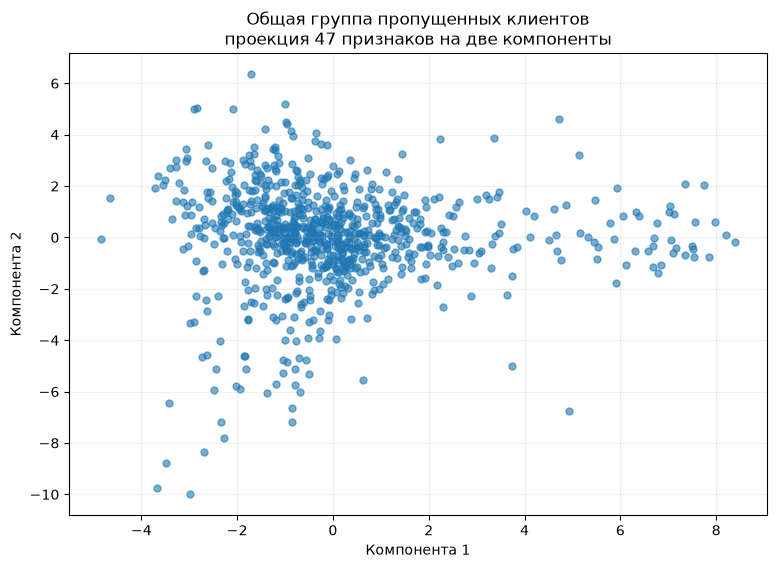

In [23]:
# ============================================================
# 5.3 Визуальная проверка внутренней структуры группы
# Цель: посмотреть, образуют ли 805 клиентов заметные скопления
# в пространстве 47 разрешённых признаков.
#
# Снижение размерности используется только для визуализации.
# Новая модель и прогнозирование не выполняются.
# ============================================================

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca = PCA(n_components=2)

X_blind_pca = pca.fit_transform(
    X_blind_scaled
)


explained = pca.explained_variance_ratio_ * 100


print("Доля информации, сохранённой в двух компонентах:")
print(f"Компонента 1: {explained[0]:.2f}%")
print(f"Компонента 2: {explained[1]:.2f}%")
print(f"Всего: {explained.sum():.2f}%")


plt.figure(figsize=(9, 6))

plt.scatter(
    X_blind_pca[:, 0],
    X_blind_pca[:, 1],
    alpha=0.6,
    s=25
)

plt.title(
    "Общая группа пропущенных клиентов\n"
    "проекция 47 признаков на две компоненты"
)

plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")

plt.grid(alpha=0.2)
plt.show()

# Результат визуальной проверки структуры группы

## Вывод

Выполнено снижение размерности 47 признаков общей группы пропущенных клиентов до двух компонент для визуальной оценки структуры.

Две компоненты сохраняют:

- первая компонента: 9.93% информации;
- вторая компонента: 8.28% информации;
- суммарно: 18.21%.

На графике наблюдается:

- основная область концентрации клиентов;
- отдельные удалённые точки;
- расширение распределения в отдельных направлениях.

## Интерпретация

Общая группа из 805 клиентов не выглядит полностью однородной.

Возможны:

- разные профили клиентов внутри группы;
- отдельные редкие случаи, сильно отличающиеся от основной массы.

Однако визуализация в двух измерениях недостаточна для определения количества подгрупп.

## Ограничения

PCA используется только для отображения структуры.

Она не определяет:

- количество групп;
- границы между группами;
- причины ошибок моделей.

## Следующий вопрос

Можно ли выделить устойчивые подгруппы внутри общей группы пропущенных клиентов?

# 6. Проверка устойчивости возможных подгрупп

## Исследовательский вопрос

Можно ли выделить устойчивые подгруппы внутри общей группы пропущенных клиентов?

## Зачем это проверять

Если 805 клиентов состоят из нескольких устойчивых профилей, это может указать на разные типы сложных случаев.

Если устойчивого разделения нет, это будет означать, что общая группа ошибок не имеет явной внутренней структуры по текущим 47 признакам.

## Ограничения

Этот анализ:

- не является новой моделью прогнозирования;
- не использует `DefMark`;
- не использует предсказания моделей;
- не оценивает качество классификации.

Цель — только описать структуру группы.

In [24]:
# ============================================================
# 6.1 Проверка вариантов внутреннего разделения группы
# Цель: оценить наличие естественных подгрупп среди 805 клиентов.
#
# Используется только пространство 47 признаков.
# Прогнозирование и обучение моделей не выполняются.
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


results = []

for n_clusters in range(2, 7):
    
    model = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_blind_scaled
    )

    score = silhouette_score(
        X_blind_scaled,
        labels
    )

    results.append(
        {
            "Количество групп": n_clusters,
            "Оценка разделения": score
        }
    )


for result in results:
    print(
        f"Группы: {result['Количество групп']} | "
        f"оценка: {result['Оценка разделения']:.3f}"
    )

Группы: 2 | оценка: 0.200
Группы: 3 | оценка: 0.199
Группы: 4 | оценка: 0.090
Группы: 5 | оценка: 0.140
Группы: 6 | оценка: 0.063


# Результат проверки возможных подгрупп

## Вывод

Проверены варианты разделения общей группы пропущенных клиентов
на 2–6 подгрупп по 47 разрешённым признакам.

Получены значения оценки разделения:

- 2 группы: 0.200
- 3 группы: 0.199
- 4 группы: 0.090
- 5 групп: 0.140
- 6 групп: 0.063

Наилучшее разделение наблюдается только при небольшом количестве групп,
но качество структуры остаётся низким.

## Интерпретация

Внутри общей группы пропущенных клиентов не обнаружено выраженной
структуры из нескольких устойчивых профилей.

Возможное слабое разделение на 2–3 группы может отражать отдельные
области похожих клиентов, но недостаточно сильное, чтобы считать их
отдельными типами ошибок.

Полученный результат больше соответствует картине:

- есть общая сложная группа клиентов;
- внутри неё нет очевидных крупных подтипов.

## Ограничения

Этот анализ не доказывает отсутствие всех возможных групп.

Он показывает только, что в текущем пространстве 47 признаков
нет сильного естественного разделения.

Кластеризация не показывает причины ошибок и не является улучшением модели.

## Следующий вопрос

Какие именно признаки сильнее всего отличают общую группу пропущенных клиентов от остальных дефолтов?

# 7. Профиль общей группы пропущенных клиентов

## Исследовательский вопрос

Есть ли признаки, по которым общая группа пропущенных клиентов отличается
от остальных дефолтных клиентов?

## Зачем это нужно

Ранее было установлено:

- существует 805 клиентов, которых не обнаружила ни одна из трёх базовых моделей;
- внутри этой группы нет очевидных одинаковых профилей;
- сильного внутреннего разделения на подгруппы не обнаружено.

Теперь проверяем другой уровень:

отличается ли сама группа от остальных дефолтов
в пространстве доступных 47 признаков.

## Ограничения

Анализ является описательным:

- не используется обучение моделей;
- не рассчитывается качество прогнозирования;
- различия признаков не интерпретируются как причинное влияние.

In [25]:
# ============================================================
# 7.1 Расчёт различий между группами
# Цель: найти признаки с наибольшим различием между:
#
# A — 805 клиентов blind spot
# B — остальные дефолтные клиенты
#
# Используются только описательные статистики.
# ============================================================

from sklearn.preprocessing import StandardScaler
import pandas as pd


# Формируем контрольную группу:
# остальные клиенты с DefMark = 1

other_defaults = df[
    (df["DefMark"] == 1)
].copy()


# Убираем клиентов blind spot

other_defaults = other_defaults.drop(
    index=blind_df.index,
    errors="ignore"
)


# Оставляем только 47 признаков

other_features = other_defaults.drop(
    columns=[
        "INN",
        "DefMark",
        "Q_B1_norm",
        "Q_B2_norm"
    ]
)


results = []


for feature in blind_features.columns:

    blind_mean = blind_features[feature].mean()
    other_mean = other_features[feature].mean()

    results.append(
        {
            "Признак": feature,
            "Среднее blind spot": blind_mean,
            "Среднее остальные дефолты": other_mean,
            "Разница": blind_mean - other_mean
        }
    )


profile_table = pd.DataFrame(results)

profile_table["Абсолютная разница"] = (
    profile_table["Разница"]
    .abs()
)


profile_table = profile_table.sort_values(
    "Абсолютная разница",
    ascending=False
)


display(
    profile_table.head(20)
)

,Признак,Среднее blind spot,Среднее остальные дефолты,Разница,Абсолютная разница
4,Q_A5_norm,13.388435,-39.208439,52.596873,52.596873
14,Q_D4_norm,7.910922,-41.769276,49.680198,49.680198
34,D5_norm,14.490512,-34.691902,49.182415,49.182415
33,D4_norm,14.611144,-34.483260,49.094404,49.094404
7,Q_B3_norm,15.673609,-31.692197,47.365806,47.365806
16,Q_D6_norm,13.702329,-26.416351,40.118680,40.118680
17,A1_norm,9.785384,-23.402085,33.187469,33.187469
10,Q_C1_norm,9.377554,-23.732547,33.110101,33.110101
30,D1_norm,7.933793,-24.248149,32.181942,32.181942
9,Q_B5_norm,8.629621,-21.874225,30.503846,30.503846


# Результат сравнения профиля blind spot и остальных дефолтов

## Вывод

Сравнение 805 клиентов общей группы пропущенных случаев
с остальными клиентами с `DefMark = 1` показало заметные различия
по ряду признаков.

Наибольшие различия наблюдаются для:

- `Q_A5_norm`;
- `Q_D4_norm`;
- `D5_norm`;
- `D4_norm`;
- `Q_B3_norm`;
- `Q_D6_norm`.

Для этих признаков средние значения группы blind spot существенно
отличаются от остальных дефолтных клиентов.

## Интерпретация

Общая группа пропущенных клиентов имеет наблюдаемый профиль,
который отличается от обычных дефолтов в текущем пространстве
47 признаков.

Это означает, что ошибки моделей не являются полностью случайными:
существует определённый набор характеристик, по которым эта группа
отличается.

Однако найденные различия являются только описательными.

Они не доказывают:

- причинное влияние признаков;
- возможность улучшения модели за счёт этих признаков;
- что именно эти признаки являются причиной ошибок.

## Ограничения

Различия между группами показывают только связь распределений.

Для поиска новых решений потребуются дополнительные исследования:
например, анализ источников информации, которые отсутствуют в текущем
feature space.

## Следующий вопрос

Есть ли признаки, которые отсутствуют или представлены недостаточно
в текущем наборе данных и могут объяснять существование blind spot?

# 8. Анализ качества данных внутри blind spot

## Исследовательский вопрос

Связана ли общая группа пропущенных клиентов с особенностями качества данных?

## Зачем это проверять

Ранее было установлено:

- группа blind spot имеет собственный профиль признаков;
- внутри группы нет явных крупных подтипов;
- ошибки моделей имеют наблюдаемый паттерн.

Теперь проверяем более простой вариант объяснения:

возможно ли, что эти клиенты отличаются не значениями признаков,
а качеством заполнения данных.

## Ограничения

Проверяется только структура данных:

- количество пропусков;
- наличие неполных строк;
- различия заполненности между группами.

Причины ошибок моделей и влияние признаков не оцениваются.

In [26]:
# ============================================================
# 8.1 Анализ пропусков в группе blind spot
# Цель: проверить, отличаются ли клиенты blind spot
# по качеству заполнения данных.
#
# Обучение моделей не выполняется.
# ============================================================


import pandas as pd


# Пропуски внутри blind spot

blind_missing = blind_features.isna().sum()


blind_missing_rate = (
    blind_features.isna()
    .mean()
    * 100
)


# Пропуски по всей рабочей выборке дефолтов

default_features = df[
    df["DefMark"] == 1
].drop(
    columns=[
        "INN",
        "DefMark",
        "Q_B1_norm",
        "Q_B2_norm"
    ]
)


default_missing_rate = (
    default_features.isna()
    .mean()
    * 100
)


missing_table = pd.DataFrame(
    {
        "Blind spot (%)": blind_missing_rate,
        "Все дефолты (%)": default_missing_rate,
        "Разница": blind_missing_rate - default_missing_rate
    }
)


missing_table = missing_table.sort_values(
    "Разница",
    ascending=False
)


display(
    missing_table.head(20)
)


print()
print("Средняя доля пропусков blind spot:")
print(round(blind_features.isna().mean().mean() * 100, 3), "%")

print()
print("Средняя доля пропусков всех дефолтов:")
print(round(default_features.isna().mean().mean() * 100, 3), "%")

,Blind spot (%),Все дефолты (%),Разница
Q_A1_norm,0.0,0.0,0.0
Q_A2_norm,0.0,0.0,0.0
Q_A3_norm,0.0,0.0,0.0
Q_A4_norm,0.0,0.0,0.0
Q_A5_norm,0.0,0.0,0.0
Q_A6_norm,0.0,0.0,0.0
Q_A7_norm,0.0,0.0,0.0
Q_B3_norm,0.0,0.0,0.0
Q_B4_norm,0.0,0.0,0.0
Q_B5_norm,0.0,0.0,0.0



Средняя доля пропусков blind spot:
0.0 %

Средняя доля пропусков всех дефолтов:
0.0 %


# Результат анализа пропусков в данных

## Вывод

Проверена заполненность признаков для:

- общей группы пропущенных клиентов (805 строк);
- остальных дефолтных клиентов.

По всем 47 разрешённым признакам:

- пропуски отсутствуют;
- различий в качестве заполнения данных не обнаружено.

## Интерпретация

Общая группа пропущенных клиентов не отличается от остальных дефолтов
по наличию пропущенных значений.

Следовательно, причина ошибок моделей не связана с простым недостатком
заполненности данных.

Полученные ранее различия связаны не с качеством данных, а с профилем
значений самих признаков.

## Ограничения

Отсутствие пропусков не означает, что в данных есть вся необходимая
информация.

Проверено только качество заполнения, а не полнота доступного сигнала.

## Следующий вопрос

Есть ли в текущих 47 признаках достаточно информации, чтобы объяснить
эту группу, или для неё требуется новый источник данных?

# 9. Итоговый вывод Stage 16 — диагностика общей группы сложных случаев

## Исследовательский вопрос

Какие особенности имеют 805 клиентов, которые не были обнаружены ни одной из трёх базовых моделей?

Цель анализа:

проверить:

- является ли эта группа случайным набором сложных случаев;
- имеет ли она общий наблюдаемый профиль;
- достаточно ли текущего набора из 47 признаков для описания таких клиентов.

---

# Проверенные вопросы

| Вопрос | Результат |
|---|---|
| Существует ли общая группа клиентов, пропущенных всеми моделями? | Да, 805 клиентов |
| Отличается ли эта группа от остальных дефолтов? | Да, обнаружен отличающийся профиль признаков |
| Связана ли группа с проблемой заполнения данных? | Нет, пропуски не обнаружены |
| Состоят ли эти клиенты из одинаковых профилей? | Нет, все профили уникальны |
| Есть ли выраженное внутреннее разделение на отдельные группы? | Не обнаружено |

---

# Основные результаты

## 1. Общая группа сложных случаев подтверждена

Выделена группа из 805 клиентов, которые одновременно:

- имеют `DefMark = 1`;
- не были обнаружены тремя базовыми моделями:
  - CatBoost;
  - XGBoost;
  - LightGBM.

Группа восстановлена по принятому правилу Stage 3 на основе сохранённых OOF-результатов.

---

## 2. Группа имеет отличающийся профиль признаков

По сравнению с остальными дефолтными клиентами обнаружены заметные различия по ряду признаков:

- `Q_A5_norm` — численность сотрудников;
- `Q_D4_norm` — количество компаний с аналогичным руководителем;
- `D5_norm` — чистая прибыль / выручка;
- `D4_norm` — финансовый показатель;
- `Q_B3_norm` — количество активных исполнительных производств;
- `Q_D6_norm` — режим налогообложения.

Таким образом, сложные для моделей клиенты отличаются не одним отдельным фактором, а комбинацией характеристик бизнеса.

---

## 3. Причина не связана с пропусками данных

Для 47 разрешённых признаков:

- пропущенные значения не обнаружены;
- заполненность группы не отличается от остальных дефолтов.

Следовательно, простое объяснение через качество данных не подтверждается.

---

## 4. Внутри группы не найдено простого разделения

Проверка структуры группы показала:

- все профили клиентов уникальны;
- сильного устойчивого разделения на несколько отдельных типов не обнаружено.

Это означает, что группа сложных случаев не сводится к нескольким очевидным шаблонам.

---

# Интерпретация результатов

Полученные результаты показывают:

805 клиентов имеют общий наблюдаемый профиль, отличный от остальных дефолтов, однако в текущем пространстве 47 признаков не обнаружено простого правила, которое объясняет их сложность для моделей.

Наиболее вероятная гипотеза:

текущий набор признаков содержит полезный сигнал, но его недостаточно для полного описания части клиентов.

Проблема выглядит не как недостаток мощности одной конкретной модели, а как возможное ограничение доступной информации.

---

# Ограничения анализа

Stage 16 не доказывает:

- причины наступления дефолта;
- причинное влияние отдельных признаков;
- что добавление конкретных новых факторов улучшит модель;
- какие именно внешние источники данных закроют обнаруженное ограничение.

Анализ показывает только наличие группы сложных случаев и возможное ограничение текущего набора информации.

---

# Следующий вопрос

Какие дополнительные источники информации потенциально могут описать клиентов, которые остаются сложными для текущих моделей?